Saving archive (1).zip to archive (1) (6).zip
<class 'pandas.core.frame.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   object 
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   object 
 4   Address               9542 non-null   object 
 5   Locality              9542 non-null   object 
 6   Locality Verbose      9542 non-null   object 
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   object 
 12  Has Table booking     9542 non-null   object 
 13  Has Online delivery   9542 non-null   object 
 14  Is delivering now     9542 non-

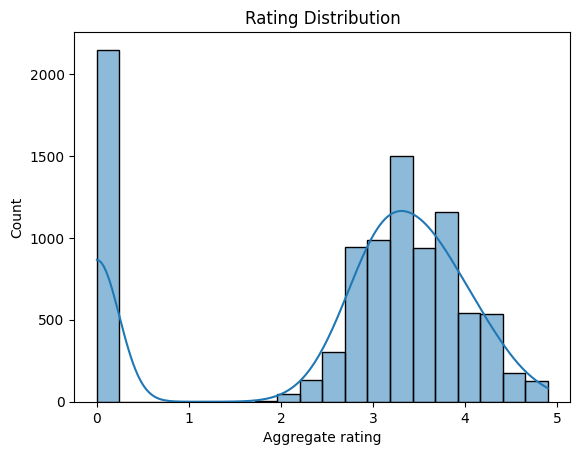

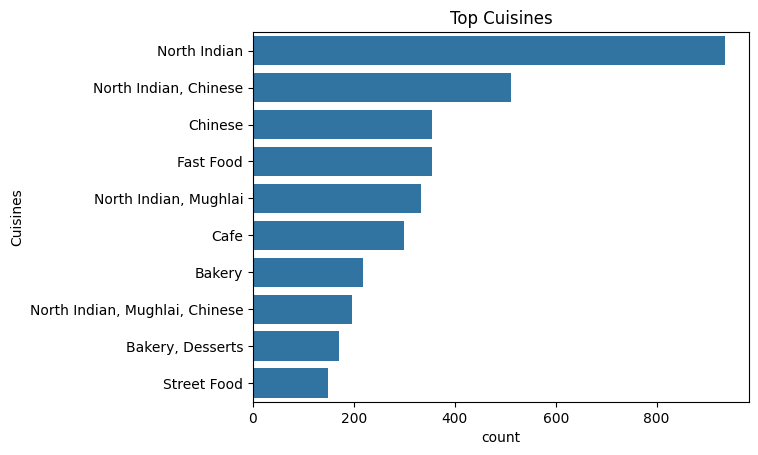

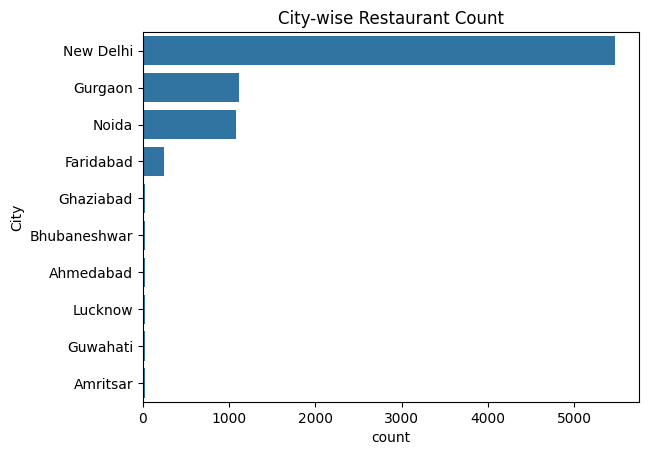

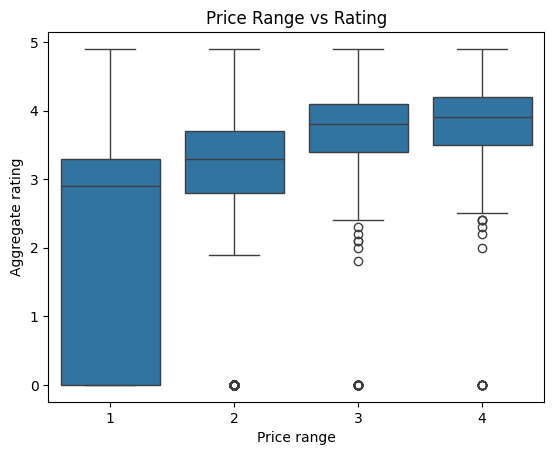

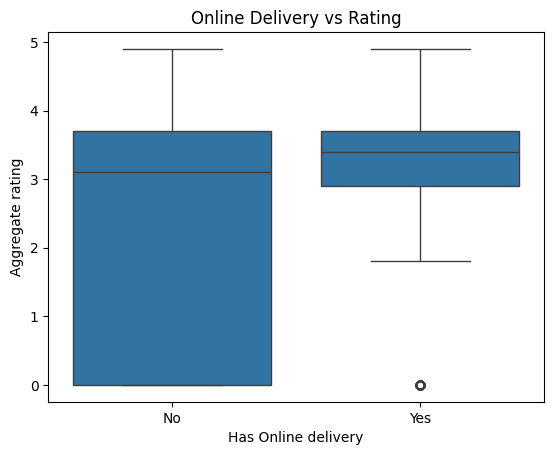

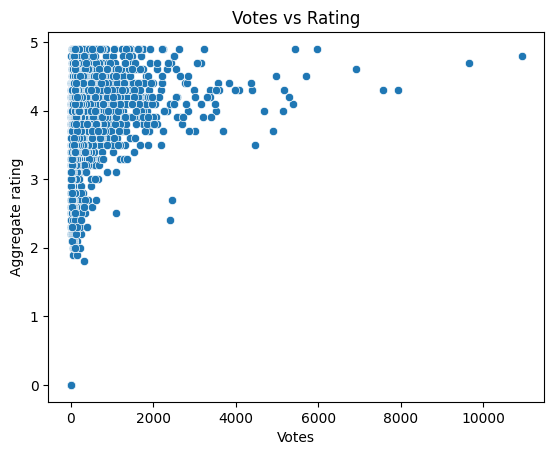

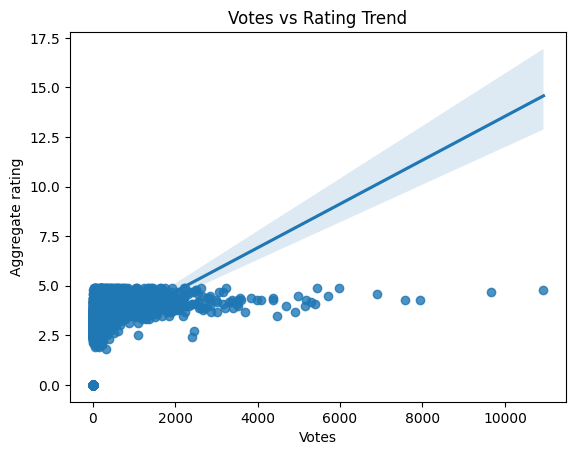

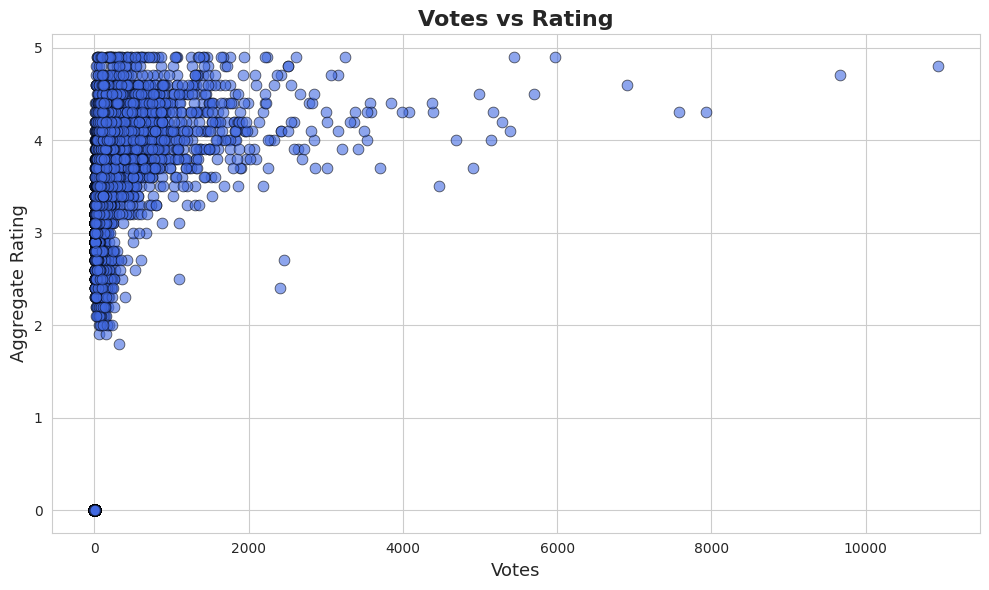

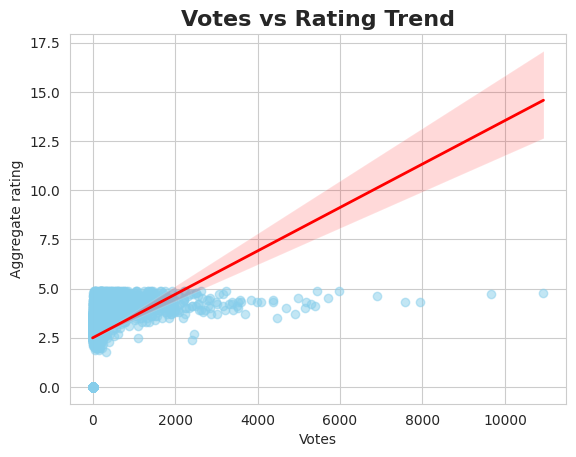

In [15]:
from google.colab import files
uploaded = files.upload()
import zipfile

# Zip file extract करना
with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall()
#यह command तुम्हें दिखाएगा कि zip के अंदर कौन‑सी files हैं — ताकि तुम सही नाम से CSV load कर सको।
import os
os.listdir()
#Load CSV File
import pandas as pd

df = pd.read_csv("zomato.csv", encoding="latin-1")
df.head()

# Duplicate हटाना
df.drop_duplicates(inplace=True)

# Missing values हटाना
df.dropna(inplace=True)

# Dataset overview
print(df.info())

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Rating Distribution
sns.histplot(df['Aggregate rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

# 2. Top 10 Cuisines
sns.countplot(y=df['Cuisines'], order=df['Cuisines'].value_counts().head(10).index)
plt.title("Top Cuisines")
plt.show()

# 3. Top 10 Cities
sns.countplot(y=df['City'], order=df['City'].value_counts().head(10).index)
plt.title("City-wise Restaurant Count")
plt.show()

# 4. Price Range vs Rating
sns.boxplot(x='Price range', y='Aggregate rating', data=df)
plt.title("Price Range vs Rating")
plt.show()

# 5. Online Delivery vs Rating
sns.boxplot(x='Has Online delivery', y='Aggregate rating', data=df)
plt.title("Online Delivery vs Rating")
plt.show()

# 6. Votes vs Rating
sns.scatterplot(x='Votes', y='Aggregate rating', data=df)
plt.title("Votes vs Rating")
plt.show()

df[['Votes', 'Aggregate rating']].corr()

sns.regplot(x='Votes', y='Aggregate rating', data=df)
plt.title("Votes vs Rating Trend")
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))  # बड़ा और साफ graph
sns.set_style("whitegrid")  # background में हल्का grid


sns.scatterplot(
    x='Votes',
    y='Aggregate rating',
    data=df,
    color='royalblue',       # सुंदर नीला रंग
    s=60,                    # points का size
    alpha=0.6,               # transparency ताकि overlap कम लगे
    edgecolor='black'        # border से points साफ दिखें
)

plt.title("Votes vs Rating", fontsize=16, fontweight='bold')
plt.xlabel("Votes", fontsize=13)
plt.ylabel("Aggregate Rating", fontsize=13)
plt.tight_layout()          # automatic spacing fix
plt.show()


sns.regplot(
    x='Votes',
    y='Aggregate rating',
    data=df,
    scatter_kws={'color':'skyblue', 'alpha':0.5},
    line_kws={'color':'red', 'linewidth':2}
)
plt.title("Votes vs Rating Trend", fontsize=16, fontweight='bold')
plt.show()

